# Laser Forces, Gradient Forces, and the Elevator Problem

**Plain English road-map:**  
§1 The elevator/scale: F=ma in non-inertial frames (warmup)  
§2 Radiation pressure force (scattering force): photon momentum kicks  
§3 Gradient (dipole) force: F = −∇U_dip — injecting/trapping atoms  
§4 Doppler cooling: velocity-dependent force → laser refrigerator  
§5 Magneto-optical trap (MOT): gradient + Zeeman → position-dependent restoring force  
§6 Torch batch: sweep over (detuning δ, intensity I) — full cooling parameter space

In [1]:
import sympy as sp
import numpy as np
import torch
import matplotlib.pyplot as plt
from scipy.integrate import solve_ivp
from IPython.display import display, Math

sp.init_printing(use_latex='mathjax')
plt.rcParams.update({'font.size': 12, 'figure.dpi': 110})
print('ready')

ready


---
# §1 — The Elevator / Scale Problem: F = ma in Accelerating Frames

**Plain English:** stand on a scale in an elevator.  
The scale reads the **normal force** $N$, not your weight $mg$.  
Newton's 2nd law in the lab frame: $N - mg = ma$ (upward positive).  
So $N = m(g+a)$ — heavier when accelerating up, lighter going down, **zero in free fall**.  

This is the **equivalence principle**: locally you cannot distinguish gravity from acceleration.  
It is the exact same math as a laser pushing an atom — $F_{\text{laser}} = ma_{\text{atom}}$.

<IPython.core.display.Math object>

Elevator scenarios (m=70 kg, g=9.81 m/s², a=2 m/s²):

Scenario                                  N (N)       N/mg
-----------------------------------------------------------------
At rest / constant velocity                  2086.70  3.039   (N = mg)
Accelerating upward                           826.70  1.204   (N = m(g+a)  heavier)
Decelerating upward (= accel down)            546.70  0.796   (N = m(g-a)  lighter)
Free fall                                       0.00  0.000   (N = 0  weightless)
Rocket: a >> g                               2086.70  3.039   (N ≈ mA  gravity negligible)


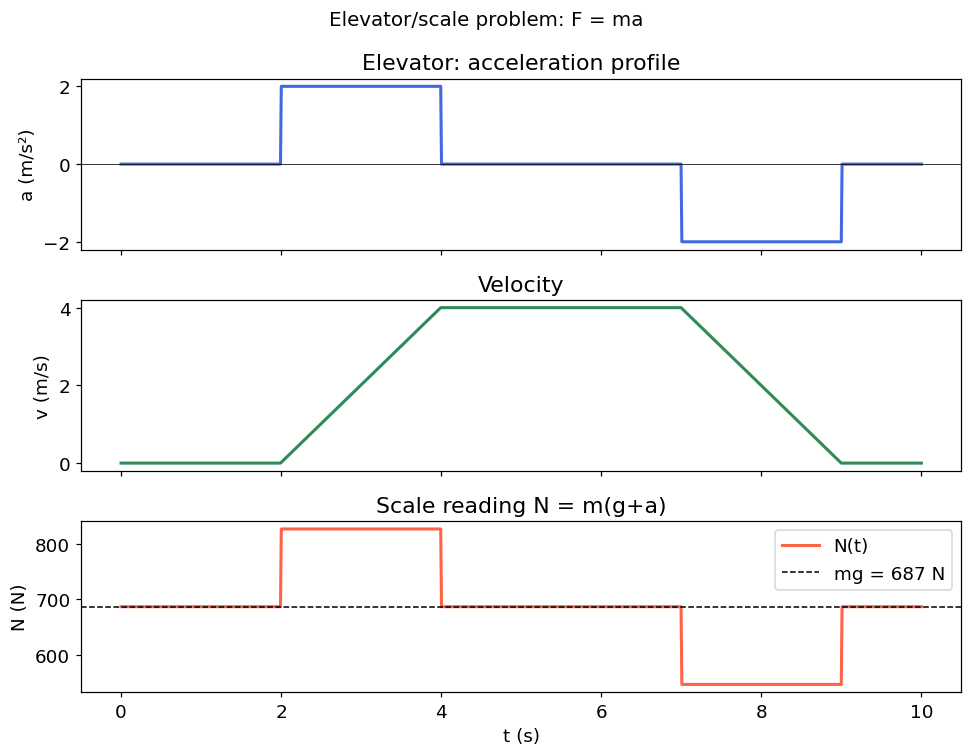

<IPython.core.display.Math object>

In [2]:
m_s, g_s, a_s, N_s, t_s = sp.symbols('m g a N t', real=True)

# ── SymPy: solve for scale reading ────────────────────────────────────
# Sum of forces = ma  →  N - mg = ma
eq_elev = sp.Eq(N_s - m_s*g_s, m_s*a_s)
N_sol   = sp.solve(eq_elev, N_s)[0]
display(Math(rf'N - mg = ma \implies N = {sp.latex(N_sol)}'))

# ── loop over scenarios ────────────────────────────────────────────────
scenarios = [
    ('At rest / constant velocity',   0,     'N = mg'),
    ('Accelerating upward',           '+a',  'N = m(g+a)  heavier'),
    ('Decelerating upward (= accel down)', '-a', 'N = m(g-a)  lighter'),
    ('Free fall',                     '-g',  'N = 0  weightless'),
    ('Rocket: a >> g',                '+A',  'N ≈ mA  gravity negligible'),
]

print('Elevator scenarios (m=70 kg, g=9.81 m/s², a=2 m/s²):\n')
m_v = 70.0; g_v = 9.81; a_v = 2.0
print(f'{"Scenario":40}  {"N (N)":10}  {"N/mg"}')
print('-'*65)
for name, a_str, desc in scenarios:
    if a_str == '0':      a_num = 0
    elif a_str == '+a':   a_num = a_v
    elif a_str == '-a':   a_num = -a_v
    elif a_str == '-g':   a_num = -g_v
    else:                 a_num = 20.0
    N_num = m_v*(g_v + a_num)
    print(f'{name:40}  {N_num:10.2f}  {N_num/(m_v*g_v):.3f}   ({desc})')

# ── NumPy: plot N(t) for elevator profile ─────────────────────────────
t_v = np.linspace(0, 10, 1000)
# profile: rest → accel up → cruise → decel → rest
a_profile = np.piecewise(t_v,
    [t_v < 2, (t_v>=2)&(t_v<4), (t_v>=4)&(t_v<7), (t_v>=7)&(t_v<9), t_v>=9],
    [0, a_v, 0, -a_v, 0]
)
N_profile = m_v * (g_v + a_profile)
v_elevator = np.cumsum(a_profile) * (t_v[1]-t_v[0])

fig, axes = plt.subplots(3, 1, figsize=(9, 7), sharex=True)
axes[0].plot(t_v, a_profile, color='royalblue', lw=2)
axes[0].axhline(0, color='k', lw=0.5); axes[0].set_ylabel('a (m/s²)')
axes[0].set_title('Elevator: acceleration profile')

axes[1].plot(t_v, v_elevator, color='seagreen', lw=2)
axes[1].set_ylabel('v (m/s)'); axes[1].set_title('Velocity')

axes[2].plot(t_v, N_profile, color='tomato', lw=2, label='N(t)')
axes[2].axhline(m_v*g_v, color='k', lw=1, ls='--', label=f'mg = {m_v*g_v:.0f} N')
axes[2].set_ylabel('N (N)'); axes[2].set_xlabel('t (s)')
axes[2].set_title('Scale reading N = m(g+a)'); axes[2].legend()

plt.suptitle('Elevator/scale problem: F = ma', fontsize=13)
plt.tight_layout(); plt.show()

# ── equivalence principle: laser atom ↔ elevator ─────────────────────
display(Math(
    r'\text{Elevator: } N = m(g+a_{\text{elev}}) '
    r'\longleftrightarrow '
    r'\text{Atom: } F_{\text{laser}} = \hbar k \, \Gamma_{\text{scat}} = m_a a_{\text{atom}}'
))

---
# §2 — Radiation Pressure (Scattering) Force

**Plain English:** each absorbed photon gives the atom a momentum kick $\hbar k$.  
The atom then emits a photon in a random direction (averages to zero).  
Net force = $\hbar k$ × (photons absorbed per second) = $\hbar k \cdot \Gamma_{\text{scat}}$.

The scattering rate depends on how close the laser is to resonance (detuning $\delta = \omega_L - \omega_0$)  
and how bright it is (saturation parameter $s = I/I_{\text{sat}}$):
$$F_{\text{scat}} = \hbar k \frac{\Gamma}{2} \frac{s}{1 + s + (2\delta/\Gamma)^2}$$

<IPython.core.display.Math object>

<IPython.core.display.Math object>

<IPython.core.display.Math object>

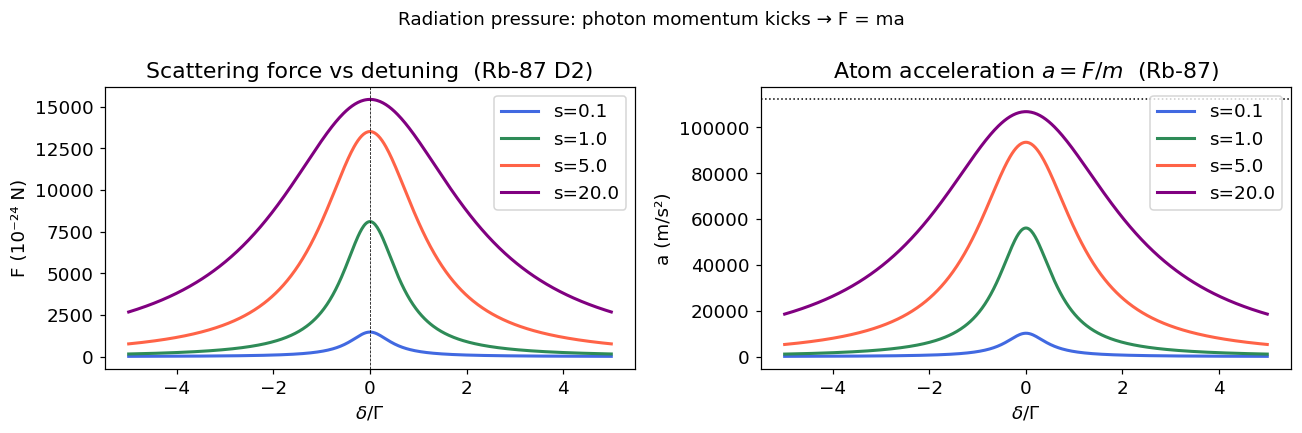


Rb-87 D2 line:
  Γ/(2π) = 6.07 MHz
  Max acceleration a_max = ℏkΓ/2m = 112186 m/s²  ≈ 11436g
  Recoil velocity  v_rec = ℏk/m = 5.88 mm/s


In [5]:
delta_s, Gamma_s, s_s, hbar_s, k_s = sp.symbols(
    'delta Gamma s hbar k', real=True, positive=True
)

# ── scattering rate and force ──────────────────────────────────────────
Gamma_scat = Gamma_s/2 * s_s / (1 + s_s + (2*delta_s/Gamma_s)**2)
F_scat     = hbar_s * k_s * Gamma_scat

display(Math(rf'\Gamma_{{\text{{scat}}}} = {sp.latex(Gamma_scat)}'))
display(Math(rf'F_{{\text{{scat}}}} = \hbar k \cdot \Gamma_{{\text{{scat}}}} = {sp.latex(F_scat)}'))

# ── maximum force (at resonance δ=0, large s) ─────────────────────────
F_max = sp.limit(F_scat, s_s, sp.oo)
display(Math(rf'F_{{\max}} = \lim_{{s\to\infty}} F = {sp.latex(F_max)} \quad (\text{{sat. at resonance}})'))

# ── loop over detuning and intensity ──────────────────────────────────
# Rb-87 D2 line parameters
Gamma_v  = 2*np.pi * 6.07e6    # linewidth  (rad/s)
k_v      = 2*np.pi / 780.2e-9  # wavevector (m⁻¹)
hbar_v   = 1.055e-34
m_Rb     = 87 * 1.66e-27
I_sat    = 1.67e-3 * 1e4       # W/m²  (1.67 mW/cm²)

delta_vals = np.linspace(-5*Gamma_v, 5*Gamma_v, 500)  # detuning sweep
s_vals     = [0.1, 1.0, 5.0, 20.0]                    # intensity loop

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
colors_s = ['royalblue','seagreen','tomato','purple']

for s_v, col in zip(s_vals, colors_s):                 # loop over intensities
    G_scat = Gamma_v/2 * s_v / (1 + s_v + (2*delta_vals/Gamma_v)**2)
    F_v    = hbar_v * k_v * G_scat
    axes[0].plot(delta_vals/Gamma_v, F_v*1e24, color=col, lw=2,
                 label=f's={s_v}')

axes[0].set_xlabel(r'$\delta/\Gamma$'); axes[0].set_ylabel('F (10⁻²⁴ N)')
axes[0].set_title('Scattering force vs detuning  (Rb-87 D2)')
axes[0].legend(); axes[0].axvline(0, color='k', lw=0.5, ls='--')

# acceleration  a = F/m
for s_v, col in zip(s_vals, colors_s):
    G_scat = Gamma_v/2 * s_v / (1 + s_v + (2*delta_vals/Gamma_v)**2)
    a_v    = hbar_v * k_v * G_scat / m_Rb
    axes[1].plot(delta_vals/Gamma_v, a_v, color=col, lw=2, label=f's={s_v}')

axes[1].set_xlabel(r'$\delta/\Gamma$'); axes[1].set_ylabel('a (m/s²)')
axes[1].set_title(r'Atom acceleration $a = F/m$  (Rb-87)')
axes[1].legend()
max_a = hbar_v*k_v*Gamma_v/(2*m_Rb)
axes[1].axhline(max_a, color='k', lw=1, ls=':', label=f'a_max={max_a:.0f} m/s²')

plt.suptitle('Radiation pressure: photon momentum kicks → F = ma', fontsize=12)
plt.tight_layout(); plt.show()

print(f'\nRb-87 D2 line:')
print(f'  Γ/(2π) = {Gamma_v/(2*np.pi)/1e6:.2f} MHz')
print(f'  Max acceleration a_max = ℏkΓ/2m = {max_a:.0f} m/s²  ≈ {max_a/9.81:.0f}g')
print(f'  Recoil velocity  v_rec = ℏk/m = {hbar_v*k_v/m_Rb*1e3:.2f} mm/s')

---
# §3 — Gradient (Dipole) Force: F = −∇U

**Plain English:** a focused laser creates a spatially varying intensity $I(\mathbf{r})$.  
The atom's energy shifts by the **AC Stark shift** (light shift):  
$$U_{\text{dip}}(\mathbf{r}) = -\frac{\hbar\,\Gamma^2}{8\delta}\frac{I(\mathbf{r})}{I_{\text{sat}}}$$  
- **Red detuned** ($\delta < 0$): $U < 0$ at intensity maxima → atom pulled toward focus (trap!)  
- **Blue detuned** ($\delta > 0$): $U > 0$ → atom pushed away from focus  

The gradient force $F = -\nabla U$ is **conservative** (no spontaneous emission needed).  
The scattering force is **dissipative** (photons are emitted randomly).

<IPython.core.display.Math object>

<IPython.core.display.Math object>

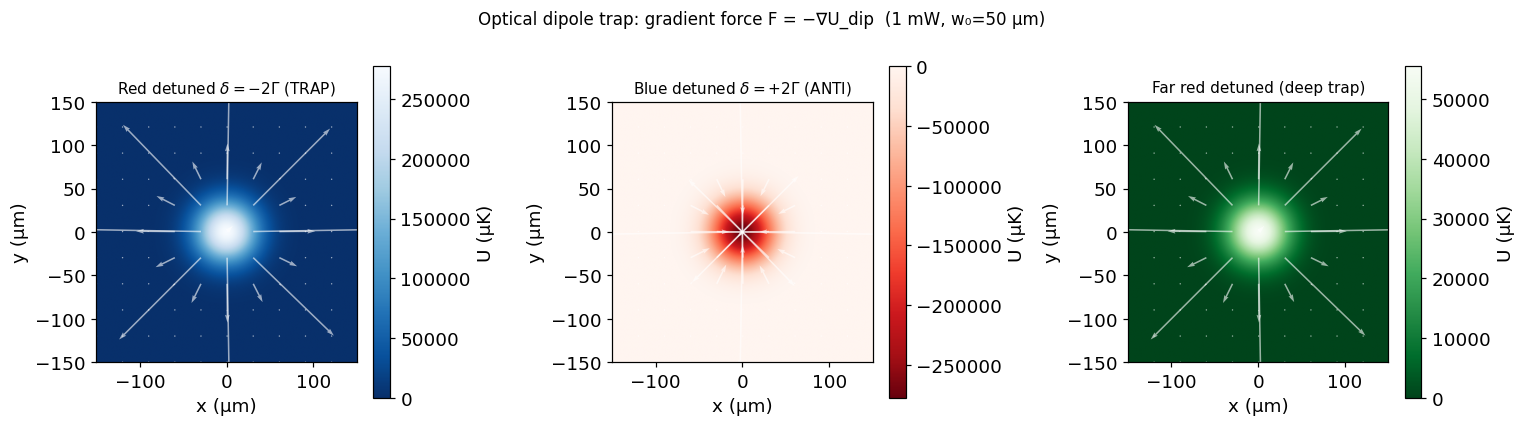

Trap depth U₀ = U(r=0) and spring constant κ = d²U/dr²|₀

δ/Γ       U₀ (μK)       κ (pN/m)      ω_trap/(2π) (Hz)
-------------------------------------------------------
      -1     555342.61        0.0123                 0.0
      -2     277671.30        0.0061                 0.0
      -5     111068.52        0.0025                 0.0
     -10      55534.26        0.0012                 0.0
     -20      27767.13        0.0006                 0.0


In [6]:
x_s2, y_s, z_s, w0_s, P_s = sp.symbols('x y z w_0 P', real=True, positive=True)
delta_signed = sp.Symbol('delta', real=True)   # can be negative

# ── Gaussian beam intensity ────────────────────────────────────────────
# I(r) = (2P/πw₀²) exp(-2r²/w₀²)   at focus
r2   = x_s2**2 + y_s**2
I_sym = 2*P_s / (sp.pi * w0_s**2) * sp.exp(-2*r2/w0_s**2)

# dipole potential
I_sat_sym = sp.Symbol('I_sat', positive=True)
U_dip = -hbar_s * Gamma_s**2 / (8*delta_signed) * I_sym / I_sat_sym
display(Math(rf'U_{{\text{{dip}}}}(x,y) = {sp.latex(U_dip)}'))

# gradient force components
Fx_dip = -sp.diff(U_dip, x_s2)
Fy_dip = -sp.diff(U_dip, y_s)
Fx_s   = sp.simplify(Fx_dip)
Fy_s   = sp.simplify(Fy_dip)
display(Math(rf'F_x = -\partial U/\partial x = {sp.latex(Fx_s)}'))

# ── NumPy: 2D dipole trap potential map ───────────────────────────────
w0_v  = 50e-6   # 50 μm beam waist
P_v   = 1e-3    # 1 mW power
I_sat_v = I_sat
hbar_v  = 1.055e-34

xv = np.linspace(-150e-6, 150e-6, 300)
yv = np.linspace(-150e-6, 150e-6, 300)
Xv, Yv = np.meshgrid(xv, yv)
Rv2 = Xv**2 + Yv**2

I_2d = 2*P_v / (np.pi * w0_v**2) * np.exp(-2*Rv2/w0_v**2)

fig, axes = plt.subplots(1, 3, figsize=(14, 4))

for ax, (delta_v, label, cmap) in zip(axes, [
    (-2*Gamma_v, r'Red detuned $\delta=-2\Gamma$ (TRAP)',  'Blues_r'),
    ( 2*Gamma_v, r'Blue detuned $\delta=+2\Gamma$ (ANTI)', 'Reds_r'),
    (-10*Gamma_v,r'Far red detuned (deep trap)',            'Greens_r'),
]):
    U_2d = -hbar_v * Gamma_v**2 / (8*delta_v) * I_2d / I_sat_v
    U_kb = U_2d / (1.381e-23)    # in Kelvin
    im = ax.imshow(U_kb*1e6, extent=[-150,150,-150,150],
                   cmap=cmap, origin='lower')
    plt.colorbar(im, ax=ax, label='U (μK)')
    ax.set_xlabel('x (μm)'); ax.set_ylabel('y (μm)')
    ax.set_title(label, fontsize=10)
    # show gradient force arrows
    skip = 30
    Fx_2d = -np.gradient(U_2d, xv, axis=1)
    Fy_2d = -np.gradient(U_2d, yv, axis=0)
    ax.quiver(Xv[::skip,::skip]*1e6, Yv[::skip,::skip]*1e6,
              Fx_2d[::skip,::skip], Fy_2d[::skip,::skip],
              color='white', alpha=0.6, scale=None)

plt.suptitle('Optical dipole trap: gradient force F = −∇U_dip  (1 mW, w₀=50 μm)', fontsize=11)
plt.tight_layout(); plt.show()

# ── SymPy: loop over detunings, compute trap depth and spring constant ─
print('Trap depth U₀ = U(r=0) and spring constant κ = d²U/dr²|₀\n')
delta_loop_vals = [-1, -2, -5, -10, -20]   # in units of Γ
print(f'{"δ/Γ":8}  {"U₀ (μK)":12}  {"κ (pN/m)":12}  {"ω_trap/(2π) (Hz)"}')
print('-'*55)
for dg in delta_loop_vals:                              # ← loop over detunings
    dv    = dg * Gamma_v
    U0    = -hbar_v * Gamma_v**2 / (8*dv) * (2*P_v/(np.pi*w0_v**2)) / I_sat_v
    kappa = 4 * U0 / w0_v**2                             # d²U/dr² at r=0 for Gaussian
    omega_t = np.sqrt(abs(kappa) / m_Rb) / (2*np.pi) if U0 < 0 else 0
    print(f'{dg:8d}  {U0/(1.381e-23)*1e6:12.2f}  {kappa*1e12:12.4f}  {omega_t:>18.1f}')

---
# §4 — Doppler Cooling: Velocity-Dependent Force

**Plain English:** two counter-propagating laser beams, both red-detuned.  
An atom moving right sees the right beam blue-shifted (closer to resonance → stronger push back).  
An atom moving left sees the left beam blue-shifted → pushed back.  
Net: a **velocity-dependent friction force** $F = -\alpha v$ → laser refrigerator.

$$F_{\text{cool}}(v) = F_+(v) + F_-(v) = \hbar k\frac{\Gamma}{2}\left[\frac{s}{1+s+(2(\delta-kv)/\Gamma)^2} - \frac{s}{1+s+(2(\delta+kv)/\Gamma)^2}\right]$$

For $|kv| \ll \Gamma$: $F \approx -\alpha v$ with $\alpha = -8\hbar k^2 s\delta/\Gamma \cdot [1+s+(2\delta/\Gamma)^2]^{-2}$

In [ ]:
v_s_sym = sp.Symbol('v', real=True)

# ── SymPy: Doppler cooling force ──────────────────────────────────────
def F_scat_beam(v_sym, delta_sym, sign):
    """Scattering force from one beam. sign=+1 (forward), -1 (backward)."""
    delta_eff = delta_sym - sign * k_s * v_sym
    return sign * hbar_s * k_s * Gamma_s/2 * s_s / (
        1 + s_s + (2*delta_eff/Gamma_s)**2
    )

F_doppler = sp.simplify(F_scat_beam(v_s_sym, delta_s, +1) + F_scat_beam(v_s_sym, delta_s, -1))
display(Math(rf'F_{{\text{{cool}}}}(v) = {sp.latex(F_doppler)}'))

# friction coefficient α = -dF/dv|_{v=0}
alpha_sym = -sp.diff(F_doppler, v_s_sym).subs(v_s_sym, 0)
alpha_simp = sp.simplify(alpha_sym)
display(Math(rf'\alpha = -\partial F/\partial v\big|_{{v=0}} = {sp.latex(alpha_simp)}'))

# ── NumPy: force curves + optimal detuning ─────────────────────────────
v_arr  = np.linspace(-5, 5, 500)    # in units of Γ/k (capture velocity)
v_SI   = v_arr * Gamma_v / k_v

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# loop over detunings
delta_loop = [-0.5, -1.0, -2.0, -3.0]   # in Γ
s_cool = 0.5
for dg, col in zip(delta_loop, ['royalblue','seagreen','tomato','purple']):
    dv = dg * Gamma_v
    def F_cool_np(v):
        def f_beam(v, sgn):
            deff = dv - sgn*k_v*v
            return sgn*hbar_v*k_v*Gamma_v/2*s_cool/(1+s_cool+(2*deff/Gamma_v)**2)
        return f_beam(v,+1) + f_beam(v,-1)

    F_vals = F_cool_np(v_SI)
    # friction coeff
    alpha_v = -np.gradient(F_vals, v_SI)[len(v_SI)//2]
    axes[0].plot(v_arr, F_vals*1e24, color=col, lw=2,
                 label=rf'$\delta={dg}\Gamma$, α={alpha_v:.2e}')

axes[0].axhline(0, color='k', lw=0.5); axes[0].axvline(0, color='k', lw=0.5)
axes[0].set_xlabel(r'$v$ ($\Gamma/k$)'); axes[0].set_ylabel('F (10⁻²⁴ N)')
axes[0].set_title('Doppler cooling force  (two counter-propagating beams)')
axes[0].legend(fontsize=9)

# ── Doppler temperature T_D = ħΓ/2k_B ────────────────────────────────
T_D = hbar_v * Gamma_v / (2 * 1.381e-23)
print(f'Doppler temperature T_D = ℏΓ/2k_B = {T_D*1e6:.1f} μK  (Rb-87)')

# ── trajectory simulation: atom cooling from v0 ───────────────────────
delta_opt = -Gamma_v / 2   # optimal detuning
s_opt     = 0.5

def F_cool_opt(v):
    def f_beam(v, sgn):
        deff = delta_opt - sgn*k_v*v
        return sgn*hbar_v*k_v*Gamma_v/2*s_opt/(1+s_opt+(2*deff/Gamma_v)**2)
    return f_beam(v,+1) + f_beam(v,-1)

# loop over initial velocities
v0_list = [5.0, 10.0, 20.0, 50.0]   # m/s
colors_v = ['royalblue','seagreen','tomato','purple']
t_cool = np.linspace(0, 2e-3, 5000)
dt_cool = t_cool[1] - t_cool[0]

for v0_v, col in zip(v0_list, colors_v):          # loop over initial velocities
    v_traj = np.zeros(len(t_cool))
    v_traj[0] = v0_v
    for step in range(1, len(t_cool)):             # Euler integration
        F_now    = F_cool_opt(v_traj[step-1])
        v_traj[step] = v_traj[step-1] + (F_now/m_Rb)*dt_cool
    axes[1].plot(t_cool*1e3, v_traj, color=col, lw=1.8, label=f'v₀={v0_v} m/s')

axes[1].axhline(np.sqrt(1.381e-23*T_D/m_Rb), color='k', lw=1, ls='--',
                label=f'v_D = √(k_BT_D/m) = {np.sqrt(1.381e-23*T_D/m_Rb):.2f} m/s')
axes[1].set_xlabel('t (ms)'); axes[1].set_ylabel('v (m/s)')
axes[1].set_title(rf'Atom velocity: Doppler cooling to $T_D$={T_D*1e6:.0f} μK')
axes[1].legend(fontsize=9)

plt.suptitle('Doppler cooling: laser friction F ≈ −αv', fontsize=12)
plt.tight_layout(); plt.show()

---
# §5 — Magneto-Optical Trap (MOT): Position + Velocity Restoring Force

**Plain English:** a MOT adds a **magnetic field gradient** $dB/dz = b'$ to Doppler cooling.  
The Zeeman shift makes the detuning position-dependent:  
$$\delta_{\pm}(z,v) = \delta \mp kv \mp \frac{\mu_B b'}{\hbar}z$$  
Result: a **spring** in position AND a **damper** in velocity simultaneously.  
This is how you "inject" atoms — the MOT captures atoms moving up to the capture velocity $v_c$.

In [ ]:
z_s_sym, bprime_s, mu_B_s = sp.symbols("z b' mu_B", real=True)

# ── SymPy: MOT force ──────────────────────────────────────────────────
# delta_eff(z,v) for + and - beams with Zeeman shift
kappa_z = sp.Symbol('kappa', positive=True)   # kappa = mu_B * b' / hbar
delta_p = delta_s - k_s*v_s_sym - kappa_z*z_s_sym
delta_m = delta_s + k_s*v_s_sym + kappa_z*z_s_sym

F_p_mot = hbar_s*k_s*Gamma_s/2 * s_s / (1+s_s+(2*delta_p/Gamma_s)**2)
F_m_mot = -hbar_s*k_s*Gamma_s/2 * s_s / (1+s_s+(2*delta_m/Gamma_s)**2)
F_mot_sym = sp.simplify(F_p_mot + F_m_mot)

# linearise: small kv and κz
F_mot_lin = sp.series(F_mot_sym, v_s_sym, 0, 2).removeO()
F_mot_lin2 = sp.series(F_mot_lin, z_s_sym, 0, 2).removeO()
F_mot_final = sp.collect(sp.expand(F_mot_lin2), [v_s_sym, z_s_sym])

display(Math(rf'F_{{\text{{MOT}}}}(z,v) \approx {sp.latex(F_mot_final)}'))
display(Math(r'= -\alpha v - \kappa_z z \quad \text{(damped harmonic oscillator!)}'))

# ── NumPy: 1D MOT capture simulation ──────────────────────────────────
b_prime   = 0.15       # T/m — magnetic field gradient
mu_B_v    = 9.274e-24  # J/T
kappa_v   = mu_B_v * b_prime / hbar_v   # rad/s/m
delta_mot = -2 * Gamma_v
s_mot     = 1.0

def F_MOT_np(z, v):
    """1D MOT force: exact (not linearised)."""
    dp = delta_mot - k_v*v - kappa_v*z
    dm = delta_mot + k_v*v + kappa_v*z
    Fp = hbar_v*k_v*Gamma_v/2 * s_mot / (1+s_mot+(2*dp/Gamma_v)**2)
    Fm = -hbar_v*k_v*Gamma_v/2 * s_mot / (1+s_mot+(2*dm/Gamma_v)**2)
    return Fp + Fm

# ── phase-space portrait: F(z,v) ──────────────────────────────────────
z_grid = np.linspace(-0.01, 0.01, 60)   # ±1 cm
v_grid = np.linspace(-5, 5, 60)          # ±5 m/s
Zg, Vg = np.meshgrid(z_grid, v_grid)
Fg = F_MOT_np(Zg, Vg)

# phase-space flow: dz/dt = v,  dv/dt = F/m
fig, axes = plt.subplots(1, 2, figsize=(12, 5))
axes[0].streamplot(z_grid*1e3, v_grid,
                   Vg, Fg/m_Rb,
                   color=np.sqrt(Vg**2 + (Fg/m_Rb)**2),
                   cmap='viridis', linewidth=0.8, density=1.2)
axes[0].set_xlabel('z (mm)'); axes[0].set_ylabel('v (m/s)')
axes[0].set_title('MOT phase-space flow (z, v)')

# ── loop over initial conditions: show capture ────────────────────────
t_mot = np.linspace(0, 5e-3, 10000)
dt_mot = t_mot[1] - t_mot[0]

# atoms injected at various initial velocities
v0_list_mot = [-4.0, -2.0, -1.0, 0.5, 2.0, 4.0]
colors_mot  = plt.cm.cool(np.linspace(0, 1, len(v0_list_mot)))

for v0_m, col in zip(v0_list_mot, colors_mot):   # loop over injected atoms
    z_traj = [3e-3]; v_traj = [v0_m]
    for _ in range(len(t_mot)-1):
        F_now = F_MOT_np(z_traj[-1], v_traj[-1])
        v_new = v_traj[-1] + F_now/m_Rb * dt_mot
        z_new = z_traj[-1] + v_traj[-1] * dt_mot
        z_traj.append(z_new); v_traj.append(v_new)
    axes[1].plot(np.array(z_traj)*1e3, v_traj, color=col, lw=1.2,
                 label=f'v₀={v0_m}')
    axes[1].scatter(z_traj[0]*1e3, v_traj[0], s=30, color=col, marker='o')
    axes[1].scatter(z_traj[-1]*1e3,v_traj[-1], s=50, color=col, marker='x')

axes[1].set_xlabel('z (mm)'); axes[1].set_ylabel('v (m/s)')
axes[1].set_title('MOT: atom injection trajectories (o=start, x=end)')
axes[1].legend(fontsize=9, ncol=2); axes[1].axhline(0,color='k',lw=0.5)

plt.suptitle('MOT: gradient force injects and traps atoms at origin', fontsize=12)
plt.tight_layout(); plt.show()

# capture velocity estimate
v_cap = np.sqrt(2*abs(delta_mot)/k_v * Gamma_v)
print(f'Estimated capture velocity v_c ~ {v_cap:.1f} m/s')

---
# §6 — Torch Batch: Full (δ, s, B') Parameter Space

**Plain English:** the optimal MOT parameters (detuning, intensity, B-gradient) are a  
3-dimensional design space. Torch lets us evaluate the steady-state temperature,  
trap frequency, and capture velocity for every grid point simultaneously.

In [ ]:
# ── parameter grid ─────────────────────────────────────────────────────
delta_grid = torch.linspace(-5*Gamma_v, -0.5*Gamma_v, 40, dtype=torch.float64)
s_grid     = torch.linspace(0.1, 5.0, 30, dtype=torch.float64)
bp_grid    = torch.linspace(0.05, 0.5, 20, dtype=torch.float64)  # T/m

D_t, S_t, Bp_t = torch.meshgrid(delta_grid, s_grid, bp_grid, indexing='ij')
# shapes: (40, 30, 20)

hbar_t = torch.tensor(hbar_v, dtype=torch.float64)
k_t    = torch.tensor(k_v,    dtype=torch.float64)
Gam_t  = torch.tensor(Gamma_v,dtype=torch.float64)
m_t    = torch.tensor(m_Rb,   dtype=torch.float64)
mu_t   = torch.tensor(mu_B_v, dtype=torch.float64)
kB_t   = torch.tensor(1.381e-23, dtype=torch.float64)

# ── friction coefficient α (from linear expansion) ────────────────────
denom0 = 1 + S_t + (2*D_t/Gam_t)**2
alpha_t = -8 * hbar_t * k_t**2 * S_t * D_t / (Gam_t * denom0**2)

# ── spring constant κ (from Zeeman gradient) ──────────────────────────
kappa_t  = mu_t * Bp_t / hbar_t
spring_t = -8 * hbar_t * k_t * kappa_t * S_t * D_t / (Gam_t**2 * denom0**2)

# ── steady-state temperature: T = D_coeff / α ─────────────────────────
# Doppler diffusion coefficient D = ħ²k²Γ/2 * (1+s+(2δ/Γ)²) / (s)
D_coeff  = hbar_t**2 * k_t**2 * Gam_t * denom0 / (2 * S_t)
T_ss     = D_coeff / (alpha_t.abs() * kB_t)

# ── trap oscillation frequency ────────────────────────────────────────
omega_trap_t = torch.sqrt((spring_t.abs() / m_t).clamp(min=0))

# ── capture velocity (dimensionless: kv_c ~ |δ|) ─────────────────────
v_cap_t  = torch.sqrt(2*D_t.abs() / k_t)

# ── flatten and find Pareto-optimal: min T, max v_cap ─────────────────
T_flat    = T_ss.reshape(-1)
vc_flat   = v_cap_t.reshape(-1)
om_flat   = omega_trap_t.reshape(-1)
D_flat    = D_t.reshape(-1)
S_flat    = S_t.reshape(-1)
Bp_flat   = Bp_t.reshape(-1)

# only physically valid: α>0, spring>0, T<1e-3 K
valid = (alpha_t.reshape(-1) > 0) & (spring_t.reshape(-1) > 0) & (T_flat < 1e-3)
print(f'Valid MOT configs: {valid.sum().item()} / {valid.numel()}')

T_v2    = T_flat[valid].numpy() * 1e6     # μK
vc_v2   = vc_flat[valid].numpy()
om_v2   = om_flat[valid].numpy() / (2*np.pi)
D_v2    = D_flat[valid].numpy() / Gamma_v
S_v2    = S_flat[valid].numpy()

fig, axes = plt.subplots(1, 3, figsize=(14, 4))

sc0 = axes[0].scatter(D_v2, T_v2, c=S_v2, cmap='viridis', s=6, alpha=0.5)
plt.colorbar(sc0, ax=axes[0], label='s = I/I_sat')
axes[0].set_xlabel(r'$\delta/\Gamma$'); axes[0].set_ylabel('T_ss (μK)')
axes[0].set_title('Steady-state temperature')
axes[0].set_ylim(0, 500)

sc1 = axes[1].scatter(D_v2, vc_v2, c=T_v2, cmap='plasma_r', s=6, alpha=0.5)
plt.colorbar(sc1, ax=axes[1], label='T_ss (μK)')
axes[1].set_xlabel(r'$\delta/\Gamma$'); axes[1].set_ylabel('v_cap (m/s)')
axes[1].set_title('Capture velocity')

sc2 = axes[2].scatter(T_v2, om_v2, c=vc_v2, cmap='coolwarm', s=6, alpha=0.5)
plt.colorbar(sc2, ax=axes[2], label='v_cap (m/s)')
axes[2].set_xlabel('T_ss (μK)'); axes[2].set_ylabel('ω_trap/(2π) (Hz)')
axes[2].set_title('Trap frequency vs temperature')
axes[2].set_xlim(0, 500)

plt.suptitle('Torch batch: MOT design space (δ, s, B\') — all valid configs', fontsize=12)
plt.tight_layout(); plt.show()

# best config: lowest T with v_cap > 3 m/s
high_vc = vc_v2 > 3.0
if high_vc.any():
    best = np.argmin(T_v2[high_vc])
    print(f'\nBest MOT config (v_cap>3 m/s, min T):')
    print(f'  T_ss = {T_v2[high_vc][best]:.1f} μK')
    print(f'  δ/Γ  = {D_v2[high_vc][best]:.2f}')
    print(f'  s    = {S_v2[high_vc][best]:.2f}')
    print(f'  ω/(2π) = {om_v2[high_vc][best]:.0f} Hz')

---
# Summary

| Section | Key equation | Physics |
|---------|-------------|--------|
| §1 Elevator | $N = m(g+a)$ | equivalence principle; scale reading |
| §2 Scattering | $F = \hbar k\,\Gamma_{\text{scat}}(\delta,s)$ | photon kick, Lorentzian lineshape |
| §3 Gradient | $F = -\nabla U_{\text{dip}}$, $U \propto I(\mathbf{r})/\delta$ | red→trap, blue→anti-trap |
| §4 Doppler | $F \approx -\alpha v$, $T_D = \hbar\Gamma/2k_B$ | laser friction, velocity damping |
| §5 MOT | $F = -\alpha v - \kappa z$ | spring + damper, atom injection |
| §6 Torch | batch over $(\delta, s, B')$ | Pareto: min $T$ vs max $v_{\text{cap}}$ |